#  Feedforward Neural Network (FNN)

Feedforward Neural Network (FNN) is a type of artificial neural network in which information flows in a single direction i.e from the input layer through hidden layers to the output layer without loops or feedback. It is mainly used for pattern recognition tasks like image and speech classification

### Binary Classification

In [4]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from keras.models import Sequential
from keras.layers import Dense


# Load data set
df=sns.load_dataset("tips")

# Preprocessing the data
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['time']=le.fit_transform(df['time'])
df['day']=le.fit_transform(df['day'])
df['smoker']=le.fit_transform(df['smoker'])

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [7]:
# creating binary target for binary classification
median_bill=df['total_bill'].median()
df['high_bill']=(df['total_bill']>median_bill).astype(int)
df.head()

,total_bill,tip,sex,smoker,day,time,size,high_bill
0,16.99,1.01,0,0,2,0,2,0
1,10.34,1.66,1,0,2,0,3,0
2,21.01,3.50,1,0,2,0,3,1
3,23.68,3.31,1,0,2,0,2,1
4,24.59,3.61,0,0,2,0,4,1


In [11]:
# Split the data into training and testing
X=df.drop(['high_bill','total_bill'],axis=1)
y=df['high_bill']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the feature
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)  # we scaled X_train because we have to normalize our features adn independent variables
X_test=scaler.transform(X_test)

In [16]:
# Build the neural network
model=tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')])
# compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
# train the model
history=model.fit(X_train,y_train,epochs=20,batch_size=32)
# evaluate the model
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Loss: {loss:.2f}")
print(f"Accuracy: {accuracy*100:.2f}")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4937 - loss: 0.8355
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5137 - loss: 0.7936 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5090 - loss: 0.7752
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.7698 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5184 - loss: 0.7348 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4596 - loss: 0.7492  
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4628 - loss: 0.7511 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5023 - loss: 0.6965 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5750 - loss: 0.6744 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5746 - loss: 0.6583 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5694 - loss: 0.6511 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6080 - loss: 0.6486
E

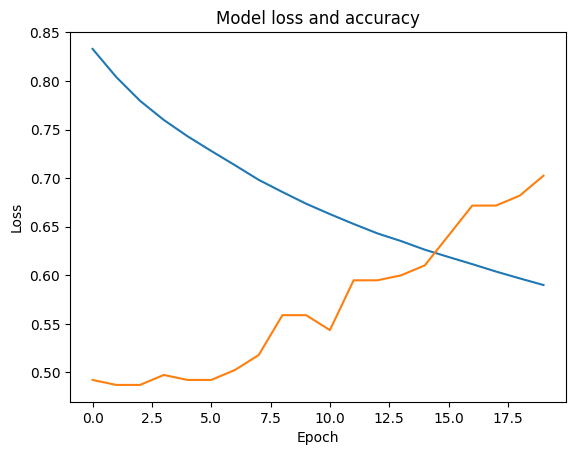

In [18]:
# plot the loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])
plt.title('Model loss and accuracy')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

# **Multi class classification**

In [19]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from keras.models import Sequential
from keras.layers import Dense


# Load data set
df=sns.load_dataset("tips")

# Preprocessing the data
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['time']=le.fit_transform(df['time'])
df['day']=le.fit_transform(df['day'])
df['smoker']=le.fit_transform(df['smoker'])

# split the data into train and test
X=df.drop(['day'],axis=1)
y=df['day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the feature
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)  # we scaled X_train because we have to normalize our features adn independent variables
X_test=scaler.transform(X_test)

# Build the neural network
model=tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(y_train.unique().shape[0],activation='softmax')])
# compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# train the model
history=model.fit(X_train,y_train,epochs=20,batch_size=32)
# evaluate the model
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Loss: {loss:.2f}")
print(f"Accuracy: {accuracy*100:.2f}")

Epoch 1/20


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2529 - loss: 1.3741
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4064 - loss: 1.2644 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5001 - loss: 1.1962 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6187 - loss: 1.1121 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6057 - loss: 1.0899
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5876 - loss: 1.0986
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6629 - loss: 0.9977
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6037 - loss: 0.9779
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 0.9780 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6063 - loss: 0.9273 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6002 - loss: 0.9271 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5766 - loss: 0.9712
Epoch 13/20

Epoch 1/50


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.5489 - val_accuracy: 0.6667 - val_loss: 0.8712
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7279 - loss: 0.5647 - val_accuracy: 0.6667 - val_loss: 0.8718
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7478 - loss: 0.5250 - val_accuracy: 0.6667 - val_loss: 0.8748
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7613 - loss: 0.5460 - val_accuracy: 0.6667 - val_loss: 0.8805
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7591 - loss: 0.5190 - val_accuracy: 0.6667 - val_loss: 0.8776
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8016 - loss: 0.5075 - val_accuracy: 0.6667 - val_loss: 0.8771
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7417 - loss: 0.5518 - val_accuracy: 0.6667 - val_loss: 0.8811
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7409 - loss: 0.5693 - val_accuracy: 0.6667 - val_loss: 0.8847
Epoch 9/50


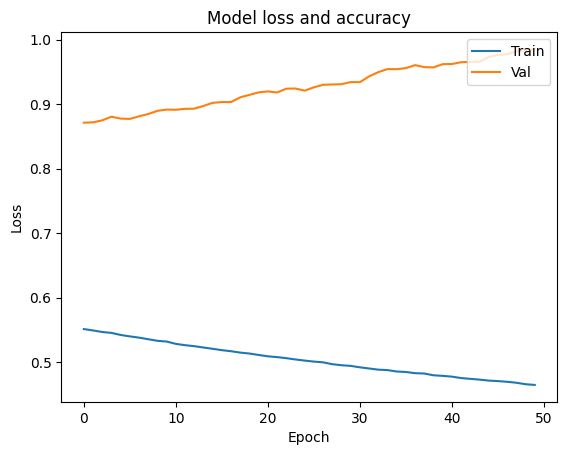

In [21]:
import matplotlib.pyplot as plt
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2)

# plot train and val loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss and accuracy')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()